In [34]:
import os
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
import pandas as pd
from tabulate import tabulate
import csv

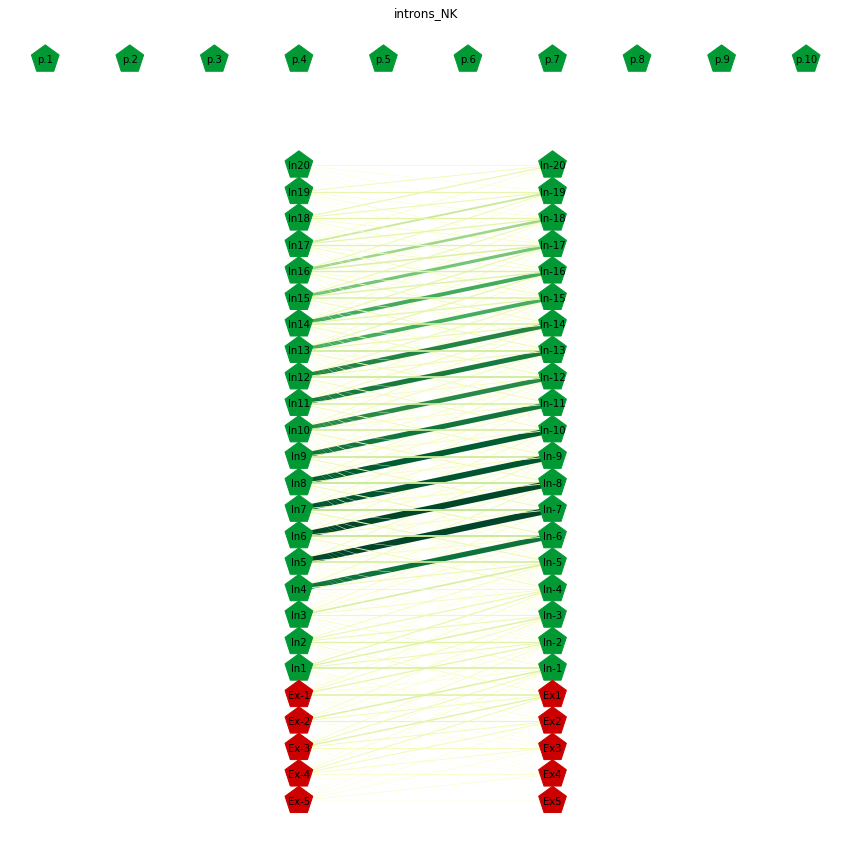

In [33]:
def index_to_label(i):
    if i in range(0,5):
        return "Ex"+str(i-5)
    if i in range(5,25):
        return "In"+str(i-4)
    if i in range(25,35):
        return "p."+str(i-24)
    if i in range(35,55):
        return "In"+str(i-55)
    if i in range(55,60):
        return "Ex"+str(i-54)

#filename, tytul = "K_25zmarginesami.dbn", "introns_K"
filename, tytul = "NK_25zmarginesami.dbn", "introns_NK"
with open(filename,'r') as plik:
    plik = plik.readlines()

    struktury=[i.split(" ")[0] for i in plik[2::3]]
    czestosc=np.zeros((60,60))
    for struktura in struktury:
        #print(len(struktura))
        pary,stos=[],[]
        for aa in range(len(struktura)):
            if struktura[aa]=="(": stos.append(aa)
            elif struktura[aa]==")":
                a=stos.pop()
                pary.append((a, aa))
        for para1,para2 in pary:
            czestosc[para1, para2]+=1  
    
    G = nx.Graph()
    for pozycja in range(25,-1,-1):
        G.add_node(pozycja, pos=(0,pozycja))
        G.add_node(59-pozycja, pos=(3,pozycja))
    for i in range(25,35):
        G.add_node(i, pos=(i-28, 28))
    for index in np.ndindex(czestosc.shape):
        w=czestosc[index]
        if w!=0: G.add_edge(index[0], index[1], weight=w)
    
    d=len(struktury)#np.max(czestosc)#np.sum(czestosc)
    czestosc=czestosc/d*100
    
    headers = [index_to_label(i) for i in range(len(czestosc))]
    ps = ["p."+str(i) for i in range(1,11)]
    t = pd.DataFrame({headers[i]:czestosc[:,i] for i in range(60)}, index=headers)
    t.drop(ps, axis=0, inplace=True)
    t.drop(ps, axis=1, inplace=True)
    #print(t.shape, t.columns, t.index)

    #table=t.to_csv(sep=",")
    #with open(directory+'tabele/%s_tabela.csv' %(tytul.replace(" ", "_")), 'w') as f:
    #with open(directory+'rysunki/table.csv', 'w') as f:
    #    f.write(table)
    
    mapping={node:index_to_label(node) for node in G.nodes()}
    G = nx.relabel_nodes(G, mapping)
    
    plt.figure(figsize=(15,15))
    plt.title(tytul)
    pos, weights = nx.get_node_attributes(G,'pos'), nx.get_edge_attributes(G, 'weight')
    edges,weights = zip(*nx.get_edge_attributes(G,'weight').items())
    
    edges = G.edges()
    allweights = sum([G[u][v]['weight'] for u,v in edges])
    colors = [G[u][v]['weight'] for u,v in edges]
    node_colors=['#cc0000' if node.startswith('Ex') else '#009933' for node in G.nodes()]
    weights = [G[u][v]['weight']/allweights*250 for u,v in edges]
    nx.draw(G, pos, edgelist=edges, node_size=850, node_color=node_colors, font_size=10, node_shape='p', edge_color=colors, width=weights, with_labels=True, edge_cmap=plt.cm.YlGn)
    #plt.savefig(directory+'rysunki/%s_graph.png' %(tytul.replace(" ", "_")))
    plt.show()